# Aula 2 · Escalando o Modelo

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-02-escalando-o-modelo.ipynb)

**Trilha de Trainees — InsperAI** · o par prático da [Aula 2](https://trilhas-insperai.vercel.app/trainees/aulas/aula-02/)

---

Na Aula 1 o modelo tinha uma variável só. Aqui ele ganha o resto, e o tema é um só:
**o vetor de entrada pode ter o que você quiser dentro** — e quase nada do
algoritmo muda para acomodar isso.

Além disso, este notebook fecha o mistério que a Aula 1 deixou em aberto: por que
o nosso gradient descent achou o $w$ certo e deixou o $b$ preso perto de zero.

Mesmo dataset da Aula 1: 1.460 imóveis reais de Ames, Iowa.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CANDIDATOS = ["dados/imoveis.csv", "../dados/imoveis.csv"]
URL = "https://raw.githubusercontent.com/AlexChequer/notebooks-insperai/main/dados/imoveis.csv"

imoveis = pd.read_csv(next((c for c in CANDIDATOS if os.path.exists(c)), URL))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

imoveis.head()

,metragem_m2,terreno_m2,quartos,banheiros,vagas_garagem,qualidade,idade_anos,preco_mil
0,158.9,785.0,3,2,2,7,5,208.5
1,117.2,891.9,3,2,2,6,31,181.5
2,165.9,1045.2,3,2,2,7,7,223.5
3,159.5,887.2,3,1,3,7,91,140.0
4,204.2,1324.8,4,2,3,8,8,250.0


## 1 · Mais de uma feature

Cada informação de entrada é uma **feature**. Com várias, a previsão vira uma soma:

$$\text{previsão} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$$

Escrever assim não escala — imagine com 200 features. Então empacota-se as
features num vetor $\mathbf{x}$, os pesos num vetor $\mathbf{w}$, e a soma inteira
vira um **produto escalar**:

$$\text{previsão} = \mathbf{w} \cdot \mathbf{x} + b$$

In [2]:
FEATURES = ["metragem_m2", "quartos", "banheiros", "vagas_garagem", "qualidade", "idade_anos"]

X = imoveis[FEATURES].to_numpy(float)   # uma linha por imóvel, uma coluna por feature
y = imoveis["preco_mil"].to_numpy(float)

print(f"X tem forma {X.shape}  →  {X.shape[0]} imóveis × {X.shape[1]} features")
print(f"y tem forma {y.shape}")
print("\nO primeiro imóvel:")
for nome, valor in zip(FEATURES, X[0]):
    print(f"  {nome:<16} {valor:>8.1f}")

X tem forma (1460, 6)  →  1460 imóveis × 6 features
y tem forma (1460,)

O primeiro imóvel:
  metragem_m2         158.9
  quartos               3.0
  banheiros             2.0
  vagas_garagem         2.0
  qualidade             7.0
  idade_anos            5.0


In [3]:
# O produto escalar, escrito dos dois jeitos — para ver que é a mesma conta
w = np.array([1.0, -5.0, 10.0, 8.0, 20.0, -0.3])   # pesos inventados, só para demonstrar
b = 20.0

soma_na_mao = sum(w[i] * X[0][i] for i in range(len(w))) + b
com_produto_escalar = X[0] @ w + b

print(f"soma escrita por extenso: {soma_na_mao:.2f}")
print(f"produto escalar (@):      {com_produto_escalar:.2f}")

# E para os 1.460 imóveis de uma vez, sem laço nenhum:
previsoes = X @ w + b
print(f"\nprevisões de todos de uma vez: {previsoes.shape}")

soma escrita por extenso: 338.40
produto escalar (@):      338.40

previsões de todos de uma vez: (1460,)


> Guarde essa notação vetorial com carinho: **sem ela a Aula 5 (redes neurais) vira
> um muro**, porque uma rede nada mais é do que muitos desses produtos escalares
> empilhados.

Agora vamos deixar o treino achar os pesos de verdade, em vez de inventá-los.
Para poder medir honestamente, separamos uma parte do dado que o modelo **não** vê
no treino.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X_treino, X_val, y_treino, y_val = train_test_split(X, y, test_size=0.3, random_state=0)

rmse = lambda modelo, Xs, ys: mean_squared_error(ys, modelo.predict(Xs)) ** 0.5

# Modelo da Aula 1: metragem sozinha
so_metragem = LinearRegression().fit(X_treino[:, [0]], y_treino)

# Modelo desta aula: as 6 features
completo = LinearRegression().fit(X_treino, y_treino)

print(f"{'':<26}{'RMSE treino':>13}{'RMSE validação':>16}")
print(f"{'só metragem (Aula 1)':<26}{rmse(so_metragem, X_treino[:, [0]], y_treino):>13.1f}{rmse(so_metragem, X_val[:, [0]], y_val):>16.1f}")
print(f"{'6 features':<26}{rmse(completo, X_treino, y_treino):>13.1f}{rmse(completo, X_val, y_val):>16.1f}")

                            RMSE treino  RMSE validação
só metragem (Aula 1)               53.8            61.1
6 features                         37.4            42.8


In [5]:
# O que o modelo aprendeu: um peso por feature
pesos = pd.DataFrame({"feature": FEATURES, "peso": completo.coef_.round(2)})
pesos.loc[len(pesos)] = ["(deslocamento b)", round(completo.intercept_, 2)]
pesos

,feature,peso
0,metragem_m2,0.83
1,quartos,-9.84
2,banheiros,-7.64
3,vagas_garagem,14.69
4,qualidade,19.97
5,idade_anos,-0.44
6,(deslocamento b),-27.68


Repare em como se lê um peso: **quanto o preço muda quando aquela feature sobe uma
unidade e as outras ficam paradas**. Um m² a mais vale alguns milhares; um ano a
mais de idade tira valor; um ponto na nota de qualidade vale bastante.

⚠️ **Cuidado com o peso como medida de importância.** Os pesos aqui não são
comparáveis entre si, porque as features estão em escalas diferentes — "1 m² a
mais" e "1 ponto de qualidade a mais" não são a mesma quantidade de mudança. Isso
só se resolve padronizando, que é o assunto da seção 4.

## 2 · Feature engineering: escolher o que entra

Se o vetor pode ter o que você quiser, a pergunta vira: **o que colocar nele?**

Uma boa feature carrega informação sobre o que você quer prever. Uma feature ruim
**não é neutra** — ela dá ao modelo mais uma maneira de se ajustar ao ruído.
Vamos testar isso na prática.

In [6]:
gerador = np.random.default_rng(42)

# 20 colunas de puro ruído, sem nenhuma relação com preço
ruido_treino = gerador.normal(size=(len(X_treino), 20))
ruido_val = gerador.normal(size=(len(X_val), 20))

com_ruido = LinearRegression().fit(np.hstack([X_treino, ruido_treino]), y_treino)

print(f"{'':<26}{'RMSE treino':>13}{'RMSE validação':>16}")
print(f"{'6 features':<26}{rmse(completo, X_treino, y_treino):>13.1f}{rmse(completo, X_val, y_val):>16.1f}")
print(f"{'6 + 20 de ruído':<26}"
      f"{mean_squared_error(y_treino, com_ruido.predict(np.hstack([X_treino, ruido_treino]))) ** 0.5:>13.1f}"
      f"{mean_squared_error(y_val, com_ruido.predict(np.hstack([X_val, ruido_val]))) ** 0.5:>16.1f}")

                            RMSE treino  RMSE validação
6 features                         37.4            42.8
6 + 20 de ruído                    37.0            43.6


O erro de **treino melhorou** e o de **validação piorou**. É o retrato do problema:
as colunas de ruído não trazem informação nenhuma, mas dão ao modelo liberdade
para encaixar coincidências do conjunto de treino — e ele usa.

**Feature entra por merecimento, não por disponibilidade.**

E o caminho contrário também existe: às vezes uma feature **transformada** vale
mais que a original. Uma suspeita razoável sobre este dado: a nota de qualidade
não deve valer linearmente — subir de 9 para 10 provavelmente vale muito mais do
que subir de 5 para 6. Se for verdade, `qualidade²` deveria ajudar.

In [7]:
qualidade_ao_quadrado = lambda M: (M[:, 4] ** 2).reshape(-1, 1)

com_transformada = LinearRegression().fit(
    np.hstack([X_treino, qualidade_ao_quadrado(X_treino)]), y_treino
)

antes = rmse(completo, X_val, y_val)
depois = mean_squared_error(
    y_val, com_transformada.predict(np.hstack([X_val, qualidade_ao_quadrado(X_val)]))
) ** 0.5

print(f"6 features:          {antes:.2f}")
print(f"6 + qualidade²:      {depois:.2f}   ({(antes - depois) / antes * 100:.1f}% melhor)")

6 features:          42.83
6 + qualidade²:      40.56   (5.3% melhor)


A suspeita estava certa: a mesma informação, elevada ao quadrado, tirou mais de 2
mil dólares do erro típico. Nenhum dado novo entrou — só uma coluna calculada a
partir de uma que já estava lá.

E repare no que acabamos de fazer: criamos $x^2$ como feature e rodamos a **mesma**
regressão linear. Isso tem nome, e é a próxima seção.

## 3 · Regressão polinomial

E se a relação não for uma reta, mas uma curva? O truque mais elegante da aula:
você **cria features novas** a partir das que tem. Se tem $x$, crie também $x^2$,
$x^3$ — e rode a **mesma** regressão linear sobre esse conjunto ampliado.

O resultado é uma curva, mas você **não mudou o algoritmo**, só a entrada. Por isso
"linear" se refere aos **parâmetros**, não ao formato do gráfico.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# O que PolynomialFeatures faz: recebe uma coluna e devolve as potências dela
exemplo = np.array([[2.0], [3.0], [10.0]])
print("entrada:")
print(exemplo.ravel())
print("\ncom grau 3 (colunas: 1, x, x², x³):")
print(PolynomialFeatures(degree=3).fit_transform(exemplo))

entrada:
[ 2.  3. 10.]

com grau 3 (colunas: 1, x, x², x³):
[[   1.    2.    4.    8.]
 [   1.    3.    9.   27.]
 [   1.   10.  100. 1000.]]


In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# De volta a uma feature só, para dar para desenhar a curva
m_treino, m_val = X_treino[:, [0]], X_val[:, [0]]

graus = [1, 2, 3, 5, 8, 12, 15]
erros_treino, erros_val = [], []

for grau in graus:
    modelo = make_pipeline(
        PolynomialFeatures(grau), StandardScaler(), LinearRegression()
    ).fit(m_treino, y_treino)
    erros_treino.append(rmse(modelo, m_treino, y_treino))
    erros_val.append(rmse(modelo, m_val, y_val))
    print(f"grau {grau:>2}: RMSE treino {erros_treino[-1]:>7.1f}   validação {erros_val[-1]:>12.1f}")

grau  1: RMSE treino    53.8   validação         61.1
grau  2: RMSE treino    53.8   validação         60.7
grau  3: RMSE treino    53.6   validação         58.3
grau  5: RMSE treino    53.0   validação        127.3
grau  8: RMSE treino    51.9   validação       1678.3
grau 12: RMSE treino    51.8   validação       1989.7
grau 15: RMSE treino    51.4   validação     138779.3


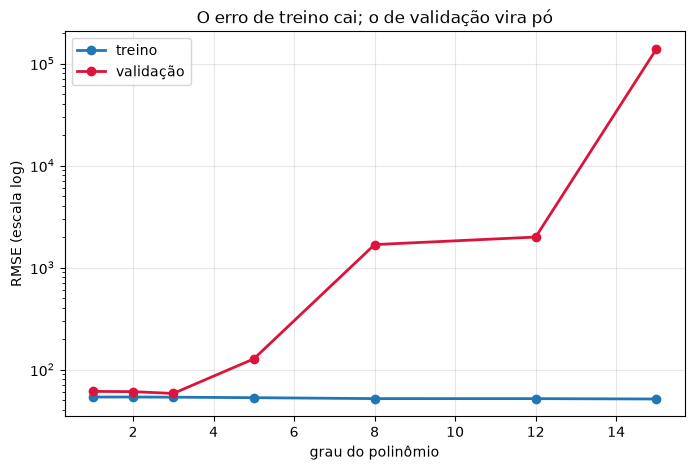

In [10]:
plt.plot(graus, erros_treino, "o-", label="treino", lw=2)
plt.plot(graus, erros_val, "o-", label="validação", lw=2, color="crimson")
plt.yscale("log")  # a validação explode; sem log, o resto vira uma linha reta
plt.xlabel("grau do polinômio")
plt.ylabel("RMSE (escala log)")
plt.legend()
plt.title("O erro de treino cai; o de validação vira pó")
plt.show()

Essa é a imagem mais importante da aula. O erro de **treino** só melhora conforme o
grau sobe — o modelo fica cada vez mais livre para se encaixar nos pontos que viu.
O erro de **validação** melhora um pouco, atinge o melhor ponto por volta do grau
3, e depois **explode**.

O grau é mais um **hiperparâmetro**: você escolhe antes de treinar, e ele tem um
ponto certo entre dois extremos ruins. Guarde essa imagem — ela volta com o nome de
**overfitting** na Aula 7.

Com 1.000 imóveis no treino, o erro de treino cai devagar. Na visualização da
página, com uma dúzia de pontos, ele chega literalmente a zero — dá para
reproduzir isso aqui:

In [11]:
# Doze pontos só, como no gráfico da página
poucos_x, poucos_y = m_treino[:12], y_treino[:12]

for grau in [1, 3, 11]:
    modelo = make_pipeline(PolynomialFeatures(grau), StandardScaler(), LinearRegression()).fit(poucos_x, poucos_y)
    print(f"grau {grau:>2} com 12 pontos → RMSE treino {rmse(modelo, poucos_x, poucos_y):>8.4f}")

grau  1 com 12 pontos → RMSE treino  29.5889
grau  3 com 12 pontos → RMSE treino  25.7718
grau 11 com 12 pontos → RMSE treino  16.5923


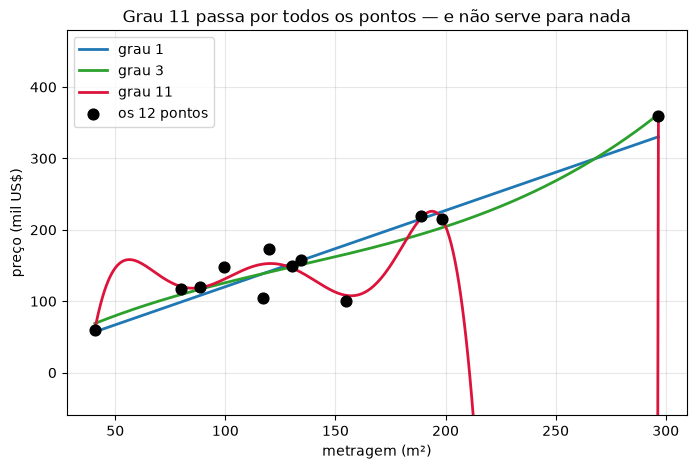

In [12]:
grade = np.linspace(poucos_x.min(), poucos_x.max(), 300).reshape(-1, 1)

for grau, cor in [(1, "tab:blue"), (3, "tab:green"), (11, "crimson")]:
    modelo = make_pipeline(PolynomialFeatures(grau), StandardScaler(), LinearRegression()).fit(poucos_x, poucos_y)
    plt.plot(grade, modelo.predict(grade), color=cor, lw=2, label=f"grau {grau}")

plt.scatter(poucos_x, poucos_y, s=60, zorder=3, color="black", label="os 12 pontos")
plt.ylim(poucos_y.min() - 120, poucos_y.max() + 120)
plt.xlabel("metragem (m²)")
plt.ylabel("preço (mil US$)")
plt.legend()
plt.title("Grau 11 passa por todos os pontos — e não serve para nada")
plt.show()

A curva de grau 11 passa por **todos** os pontos e tem erro de treino praticamente
zero. Ela decorou o ruído, não a tendência: numa metragem nova, ela chuta qualquer
coisa.

## 4 · A escala atrapalha o treino

Agora o mistério da Aula 1. Lá, o gradient descent achou o $w$ certo e deixou o $b$
preso perto de zero. A causa é a **escala**.

A metragem vale na casa das centenas; o $b$ é somado direto ao preço. A tigela de
custo, que com escalas parecidas é redonda, vira um **vale comprido e estreito**:
íngreme numa direção, quase plana na outra. O gradiente aponta forte na direção
íngreme e fraco na plana — então o treino ziguezagueia e se arrasta.

A solução é deixar as features comparáveis. **Padronizar** é recentrar cada uma
para ter média 0 e desvio 1:

$$x_{\text{pad}} = \frac{x - \mu}{\sigma}$$

In [13]:
def gradient_descent(x, y, alfa, iteracoes, w=0.0, b=0.0):
    """O mesmo da Aula 1, sem uma vírgula de diferença."""
    historico = []
    for _ in range(iteracoes):
        residuo = y - (w * x + b)
        historico.append(np.mean(residuo ** 2))
        w = w - alfa * (-2 * np.mean(x * residuo))
        b = b - alfa * (-2 * np.mean(residuo))
    return w, b, np.array(historico)


metragem = imoveis["metragem_m2"].to_numpy(float)
preco = imoveis["preco_mil"].to_numpy(float)

# A solução exata, para servir de gabarito
w_exato, b_exato = np.polyfit(metragem, preco, 1)

# (a) no dado cru, como na Aula 1
w_cru, b_cru, hist_cru = gradient_descent(metragem, preco, alfa=2e-5, iteracoes=300)

# (b) padronizando a metragem primeiro
media, desvio = metragem.mean(), metragem.std()
metragem_pad = (metragem - media) / desvio
w_pad, b_pad, hist_pad = gradient_descent(metragem_pad, preco, alfa=0.1, iteracoes=300)

# Desfaz a padronização, para comparar na escala original
w_convertido = w_pad / desvio
b_convertido = b_pad - w_pad * media / desvio

print(f"{'':<22}{'w':>10}{'b':>10}{'custo':>12}")
print(f"{'exato (gabarito)':<22}{w_exato:>10.4f}{b_exato:>10.2f}{np.mean((preco - (w_exato * metragem + b_exato)) ** 2):>12.1f}")
print(f"{'GD no dado cru':<22}{w_cru:>10.4f}{b_cru:>10.2f}{hist_cru[-1]:>12.1f}")
print(f"{'GD padronizado':<22}{w_convertido:>10.4f}{b_convertido:>10.2f}{np.mean((preco - (w_convertido * metragem + b_convertido)) ** 2):>12.1f}")

                               w         b       custo
exato (gabarito)          1.1532     18.57      3140.0
GD no dado cru            1.2707      0.03      3176.8
GD padronizado            1.1532     18.57      3140.0


**Mistério resolvido.** Padronizando, o mesmo gradient descent — o mesmíssimo
código — chega exatamente no gabarito, $b$ incluído.

E chega **muito** mais rápido:

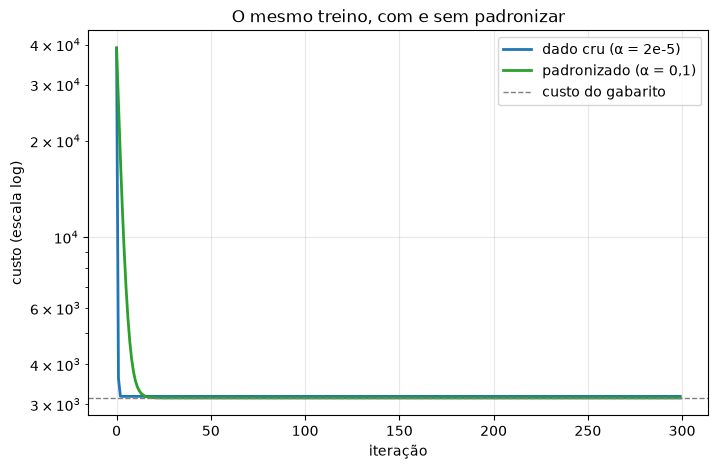

padronizado,  10 iterações → custo   3553.9
padronizado,  20 iterações → custo   3144.7
padronizado,  50 iterações → custo   3140.0
cru,          300 iterações → custo   3176.8


In [14]:
plt.plot(hist_cru, label="dado cru (α = 2e-5)", lw=2)
plt.plot(hist_pad, label="padronizado (α = 0,1)", lw=2, color="tab:green")
plt.axhline(3140.0, color="gray", ls="--", lw=1, label="custo do gabarito")
plt.yscale("log")
plt.xlabel("iteração")
plt.ylabel("custo (escala log)")
plt.legend()
plt.title("O mesmo treino, com e sem padronizar")
plt.show()

for its in [10, 20, 50]:
    ww, bb, _ = gradient_descent(metragem_pad, preco, alfa=0.1, iteracoes=its)
    wo, bo = ww / desvio, bb - ww * media / desvio
    print(f"padronizado, {its:>3} iterações → custo {np.mean((preco - (wo * metragem + bo)) ** 2):>8.1f}")
print(f"cru,          300 iterações → custo {hist_cru[-1]:>8.1f}")

Cinquenta iterações no dado padronizado batem trezentas no dado cru — e ainda
chegam num lugar melhor. O modelo final é o mesmo; o que muda é o **caminho** até
ele.

## 5 · O erro caro: vazamento de dados

Padronizar exige calcular média e desvio. **Sobre quais dados?**

Só sobre o **treino**. Se você calcular sobre o conjunto inteiro, informação do
dado de validação entra no treino pela porta dos fundos, e você passa a se enganar
sobre o quão bom o seu modelo é.

In [15]:
metragem_treino = X_treino[:, 0]
metragem_val = X_val[:, 0]

media_certa, desvio_certo = metragem_treino.mean(), metragem_treino.std()
media_errada, desvio_errado = metragem.mean(), metragem.std()  # usou o conjunto inteiro

print(f"{'':<34}{'média':>10}{'desvio':>10}")
print(f"{'só o treino (certo)':<34}{media_certa:>10.3f}{desvio_certo:>10.3f}")
print(f"{'treino + validação (vazamento)':<34}{media_errada:>10.3f}{desvio_errado:>10.3f}")
print("\nSão números diferentes — e o segundo só existe porque alguém olhou dados")
print("que deveriam estar guardados.")

                                       média    desvio
só o treino (certo)                  141.411    48.082
treino + validação (vazamento)       140.792    48.801

São números diferentes — e o segundo só existe porque alguém olhou dados
que deveriam estar guardados.


Aqui a diferença entre os dois é pequena, e o modelo mal muda. O problema não é o
tamanho do estrago **neste** caso: é que a prática está errada e o estrago cresce
em silêncio quando a transformação é mais agressiva (seleção de features,
preenchimento de faltantes, remoção de outliers).

A regra que salva: **a escala faz parte do modelo.** Aprendida no treino, aplicada
tal e qual em qualquer dado novo. No scikit-learn isso é o que `Pipeline` garante
de graça — o `fit` só toca no treino.

```python
modelo = make_pipeline(StandardScaler(), LinearRegression())
modelo.fit(X_treino, y_treino)     # o scaler aprende SÓ aqui
modelo.predict(X_val)              # e é só aplicado aqui
```

O assunto volta com todo o rigor na Aula 7.

---

## 🔬 Desafio

**1.** Descubra qual das 6 features sozinha prevê melhor o preço. Treine um modelo
por feature e compare o RMSE de validação.

<details><summary>Resposta</summary>

```python
for i, nome in enumerate(FEATURES):
    m = LinearRegression().fit(X_treino[:, [i]], y_treino)
    print(f"{nome:<16} RMSE validação {rmse(m, X_val[:, [i]], y_val):>7.1f}")
```

`qualidade` costuma ganhar da `metragem` — uma nota que resume acabamento,
material e estado carrega mais informação sobre preço do que o tamanho puro.
</details>

**2.** No gráfico do U, o melhor grau foi 3. Teste os graus 1 a 6 e ache o melhor
com mais precisão. Vale a pena passar do grau 1?

<details><summary>Resposta</summary>

```python
for grau in range(1, 7):
    m = make_pipeline(PolynomialFeatures(grau), StandardScaler(), LinearRegression()).fit(m_treino, y_treino)
    print(f"grau {grau}: RMSE validação {rmse(m, m_val, y_val):.2f}")
```

O ganho do grau 1 para o 3 é real mas pequeno. A lição: nem toda relação torta
precisa de polinômio, e a validação é quem decide — não o gráfico.
</details>

**3.** Padronize as 6 features e treine de novo com `LinearRegression`. O RMSE
muda? E os pesos?

<details><summary>Resposta</summary>

```python
padronizado = make_pipeline(StandardScaler(), LinearRegression()).fit(X_treino, y_treino)
print(f"sem padronizar: {rmse(completo, X_val, y_val):.2f}")
print(f"padronizado:    {rmse(padronizado, X_val, y_val):.2f}")

pd.DataFrame({"feature": FEATURES,
              "peso cru": completo.coef_.round(2),
              "peso padronizado": padronizado[-1].coef_.round(2)})
```

O RMSE é **igual**: o `LinearRegression` resolve por álgebra exata, sem gradient
descent, então a escala não o atrapalha. Quem sofre com escala é o treino
iterativo — e as redes neurais, da Aula 5 em diante, são todas iterativas.

Já os **pesos** mudam de leitura: padronizados, eles passam a ser comparáveis entre
si, porque agora "uma unidade" quer dizer "um desvio padrão" em todas as features.
</details>

---

## O que ficou

- O vetor de entrada pode ter o que você quiser: a previsão é um **produto
  escalar** $\mathbf{w} \cdot \mathbf{x} + b$, e o algoritmo de treino não muda.
- **Feature ruim não é neutra** — 20 colunas de ruído melhoraram o treino e
  pioraram a validação.
- **Regressão polinomial é feature engineering**, não um método novo. Grau alto
  demais decora o ruído.
- **A escala não muda onde está o mínimo, muda o caminho até ele** — e foi ela que
  prendeu o $b$ na Aula 1.
- Média e desvio saem **só do treino**. A escala faz parte do modelo.

**Anterior:** [Aula 1 — Regressão Linear](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/trainees/aula-01-regressao-linear.ipynb)